# 02 · 梯度提升的直覺：逐步糾錯

「梯度提升」聽起來嚇人，核心其實一句話：**每棵新樹，專門去擬合前面所有樹加起來還沒修好的「殘差」**。這堂課用一個一維迴歸的例子，把這個過程一輪一輪畫給你看。

## 學習目標

- 理解 boosting = **不斷擬合殘差**
- 親眼看到「加一棵樹、誤差就縮小一點」
- 理解 **learning rate（學習率）** 在控制什麼

## 1. 手動做三輪 boosting

造一條彎曲的資料。第 0 步先用「全體平均」當最爛的預測，看殘差；然後種一棵淺樹去擬合殘差，加回去；再看新的殘差……重複。

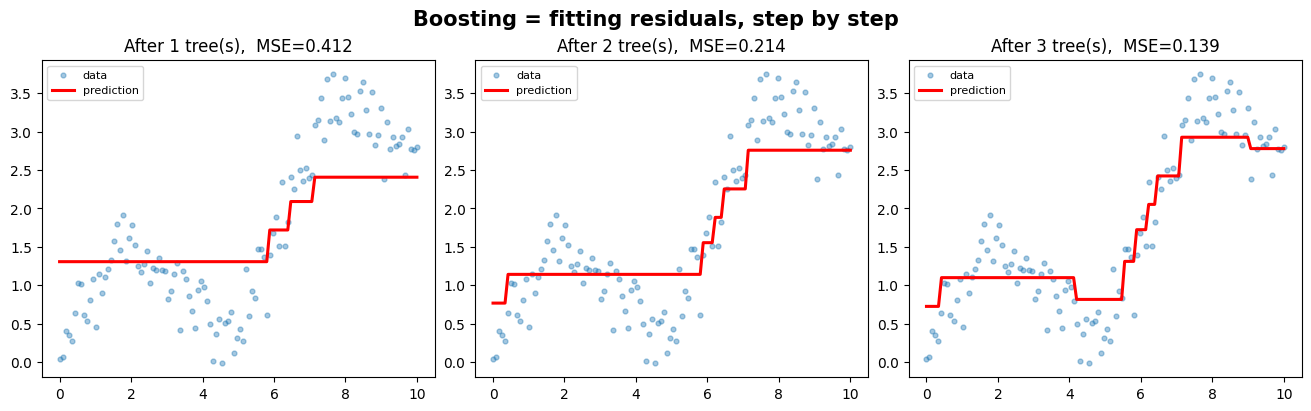

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(0)
X = np.linspace(0, 10, 120).reshape(-1, 1)
y = np.sin(X).ravel() + 0.3 * X.ravel() + rng.normal(0, 0.3, 120)

pred = np.full_like(y, y.mean())   # 第 0 步：全部猜平均
lr = 0.5                            # 學習率：每棵樹只採納一半

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for step, ax in enumerate(axes):
    residual = y - pred                              # 目前還沒修好的部分
    stump = DecisionTreeRegressor(max_depth=2).fit(X, residual)
    pred = pred + lr * stump.predict(X)              # 把新樹的修正加回去
    ax.scatter(X, y, s=12, alpha=0.4, label="data")
    ax.plot(X, pred, color="red", lw=2.2, label="prediction")
    ax.set_title(f"After {step + 1} tree(s),  MSE={np.mean((y - pred) ** 2):.3f}")
    ax.legend(fontsize=8)
fig.suptitle("Boosting = fitting residuals, step by step", fontsize=15, fontweight="bold")
plt.show()

看那條紅線：每加一棵淺樹，它就更貼合資料一點、MSE 就掉一點。這就是 boosting——**一群弱樹，靠接力修正，疊成一個強模型**。

## 2. learning rate 在做什麼？

上面的 `lr=0.5` 讓每棵樹只採納一半的修正。學習率小（如 0.1）→ 每步更保守、需要更多棵樹，但通常**更不容易過擬合、最終更準**。這是 boosting 最重要的旋鈕之一，下一課用 XGBoost 會再遇到。

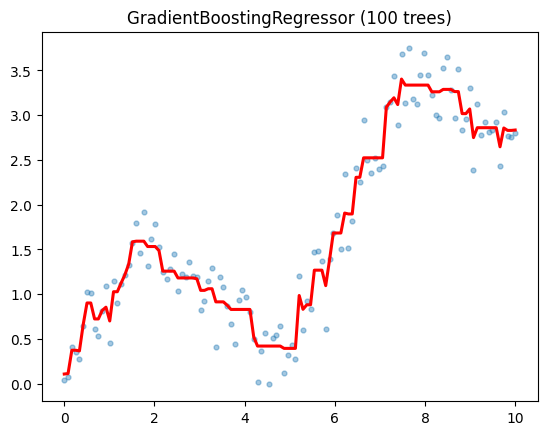

100 棵樹的 MSE: 0.038


In [2]:
from sklearn.ensemble import GradientBoostingRegressor

# sklearn 已經把上面那套流程包好了
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2)
gbr.fit(X, y)
plt.scatter(X, y, s=12, alpha=0.4)
plt.plot(X, gbr.predict(X), color="red", lw=2.2)
plt.title("GradientBoostingRegressor (100 trees)")
plt.show()
print(f"100 棵樹的 MSE: {np.mean((y - gbr.predict(X)) ** 2):.3f}")

## 小結

- 梯度提升 = 每棵新樹擬合「目前的殘差」，逐步把誤差糾正掉。
- **learning rate** 控制每棵樹採納多少修正；小學習率 + 多棵樹通常更穩更準。
- `GradientBoostingRegressor` / `Classifier` 把整套流程包好了。

## 練習

1. 把手動範例的 `lr` 改成 0.1 和 1.0，比較三輪後的 MSE 與紅線的樣子。
2. 把 sklearn 版的 `learning_rate` 調到 0.01，要幾棵樹（`n_estimators`）才追得上原本的 MSE？

下一課，換上工業界最常用的利器：**XGBoost**。